In [1]:
import re
import random
from PIL import Image
from IPython.display import display, HTML
import pandas as pd
import numpy as np 
import requests
import datetime
from bs4 import BeautifulSoup 
from tqdm import tqdm
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
from itertools import product

In [2]:
pio.kaleido.scope.mathjax = None
pio.templates.default = "plotly_white"

In [3]:
random.seed(42)

In [59]:
BASE_COLS = ["season", "team", "period", "field", "gf", "ga", "result", "goal_diff", "match", "points", ]
INDEX_PERIOD_MAP = pd.DataFrame({"period": [1, 2, 3, "ot", "so"]})
OFFSET_VAL = 0.025
COLOR_MAP = {
    1: "#d0d0d0",
    "1.": "#d0d0d0", 
    2: "#a8a8a8",
    "2.": "#a8a8a8",
    3: "#808080",
    "3.": "#808080",
    "F": "rgb(59,172,170)",
    "Konečný výsledek": "#103A71",
}
COLOR_MAP_SHORT = {
    1: "#7790C9",
    "1.": "#7790C9", 
    2: "#215CA9",
    "2.": "#215CA9",
    3: "#103A71",
    "3.": "#103A71",
}
KVA_COLOR = "rgb(59,172,170)"
PERIOD_MAP = {
    1: "1.",
    2: "2.",
    3: "3.",
    "F": "Konečný výsledek"
}
RESULTS_POINTS = {
    'R': 1, 
    'P': 0, 
    'V': 3, 
    'VN': 2, 
    'PN': 1, 
    'VP': 2, 
    'PP': 1,
}
AVG_LABELS = {
    "gat": "Průměr gólů celkem",
    "gfa": "Průměr vstřelených gólů",
    "gaa": "Průměr obdržených gólů", 
}

In [5]:
results = "https://www.hokej.cz/tipsport-extraliga/zapasy?matchList-view-displayAll=1&matchList-filter-season=2025&matchList-filter-competition=7397"

In [6]:
def aggregate_match(match: pd.DataFrame,) -> list[int]:
    gf = match["gf"].sum()
    ga = match["ga"].sum()
    goal_diff = gf - ga 
    periods = len(match)
    
    if goal_diff > 0:
        result_map = {3: "V", 4: "VP", 5: "VN"}
    elif goal_diff < 0:
        result_map = {3: "P", 4: "PP", 5: "PN"}
    else:
        result_map = {}

    result = result_map.get(periods, "R")

    return pd.DataFrame(
        [[gf, ga, goal_diff, result, "F"]], 
        columns=["gf", "ga", "goal_diff", "result", "period"],
                       )

In [7]:
def finalize_results(
    period: pd.DataFrame, 
    team: str, 
    field: str, 
    season_name: str,
    match: int,
                    ) -> pd.DataFrame: 
    
    team_res = period.copy()
    
    agg_res = aggregate_match(team_res)

    team_res["goal_diff"] = team_res["gf"] - team_res["ga"]
    team_res["result"] = pd.cut(
        team_res["gf"] - team_res["ga"],
        bins=[-float("inf"), -1, 0, float("inf")],
        labels=["P", "R", "V"]
                                )

    team_res = pd.concat([team_res, agg_res], ignore_index=True)   
    
    team_res["team"] = team
    team_res["field"] = field
    team_res["season"] = season_name
    team_res["match"] = match
    team_res["points"] = team_res["result"].map(RESULTS_POINTS)
    
    
    return team_res[BASE_COLS]

In [8]:
def period_extraction(period_raw: str) -> pd.DataFrame:
    
    scores = re.findall(r"(\d+):(\d+)", period_raw)
    results = [[int(a), int(b)] for a, b in scores]
    results_df = pd.DataFrame(np.array(results), columns=["gf", "ga"])

    return pd.merge(results_df, INDEX_PERIOD_MAP, left_index=True, right_index=True)

In [9]:
def extract_round_results(table_round: str, season_name: str) -> [pd.DataFrame, str]: 
    
    round_results = []
    
    for tr in table_round.find_all("tr", class_="js-preview__link"):
        
        team_h, team_a = [span.text.strip() for span in tr.find_all("span", class_="preview__name--short")]
        match_nr = tr.get("data-href").split("/")[-1] if tr.get("data-href") else None
        
        try:
            period_td = tr.find("td", class_="preview__period").get_text(" ", strip=True)
            period_results = period_extraction(period_td)
            round_results.append(finalize_results(period_results, team_h, "D", season_name, match_nr))
            round_results.append(
                finalize_results(period_results.rename(
                    columns={"ga": "gf", "gf": "ga", "period": "period"}), team_a, "V", season_name, match_nr
                                                       )
                                )
            
        except: 
            print(f" {team_h}vs{team_a}", end=" ")

    if len(round_results) > 0:
        return pd.concat(round_results, ignore_index=True)

In [10]:
def extract_table(url_link) -> pd.DataFrame: 
    
    season = int(re.search(r'season=(\d+)', url_link).group(1))
    season_name = str(season) + "/" + str(season+1)
    r = requests.get(url_link)
    bs = BeautifulSoup(r.content, 'html.parser')
    table = bs.find_all("table", class_="preview")
    
    complete_rounds = []

    print("Not played matches:", end=" ")
    for table_round in table:
        complete_rounds.append(extract_round_results(table_round, season_name))
    print("\n>>> data fetched <<<")
    
    return pd.concat(complete_rounds, ignore_index=True)       

In [11]:
%%time
tables_df = extract_table(results)

Not played matches:  KVAvsLIB  PCEvsKOM  MBLvsSPA  PLZvsSPA  SPAvsMHK  SPAvsCEB  SPAvsKOM  CEBvsPLZ  MBLvsPCE  VITvsLIT  LIBvsTRI  MHKvsKLA  OLOvsKVA  VITvsKOM  KLAvsOLO  LIBvsLIT  KVAvsSPA  PLZvsMHK  MBLvsTRI  PCEvsCEB  PLZvsTRI  MBLvsVIT  CEBvsKLA  OLOvsPCE  MHKvsKVA  LIBvsKOM  TRIvsCEB  LITvsOLO  KVAvsMBL  KLAvsLIB  PCEvsPLZ  KOMvsMHK  SPAvsOLO  PLZvsKOM  CEBvsKVA  MBLvsLIT  LIBvsVIT  PCEvsKLA  MHKvsTRI  TRIvsPCE  LITvsMHK  KLAvsPLZ  KVAvsLIB  SPAvsMBL  KOMvsCEB  MBLvsOLO  PLZvsKVA  CEBvsLIT  KLAvsTRI  MHKvsVIT  LIBvsSPA  PCEvsKOM  LITvsPCE  MBLvsLIB  VITvsCEB  OLOvsMHK  KVAvsKLA  KOMvsTRI  SPAvsPLZ  PCEvsKVA  TRIvsVIT  KLAvsKOM  LIBvsOLO  MHKvsSPA  PLZvsLIT  CEBvsMBL  OLOvsCEB  MBLvsPLZ  LIBvsMHK  VITvsPCE  SPAvsKLA  LITvsTRI  KVAvsKOM  PCEvsSPA  PLZvsVIT  KLAvsLIT  KOMvsOLO  MHKvsMBL  CEBvsLIB  TRIvsKVA 
>>> data fetched <<<
CPU times: user 1.59 s, sys: 11.4 ms, total: 1.6 s
Wall time: 1.98 s


In [12]:
tables_df.head(10)

,season,team,period,field,gf,ga,result,goal_diff,match,points
0,2025/2026,CEB,1,D,1,1,R,0,2921768,1
1,2025/2026,CEB,2,D,0,1,P,-1,2921768,0
2,2025/2026,CEB,3,D,1,1,R,0,2921768,1
3,2025/2026,CEB,F,D,2,3,P,-1,2921768,0
4,2025/2026,SPA,1,V,1,1,R,0,2921768,1
5,2025/2026,SPA,2,V,1,0,V,1,2921768,3
6,2025/2026,SPA,3,V,1,1,R,0,2921768,1
7,2025/2026,SPA,F,V,3,2,V,1,2921768,3
8,2025/2026,TRI,1,D,1,1,R,0,2921766,1
9,2025/2026,TRI,2,D,4,1,V,3,2921766,3


In [13]:
def define_offset(df: pd.DataFrame, sort_by: str, output: str) -> dict: 

    sorted_df = df.copy().sort_values(by=sort_by, ascending=False).reset_index(drop=True)
    sorted_df["offset"] = sorted_df.index
    sorted_df["offset"] = sorted_df["offset"].apply(
        lambda x: 0 if x % 3 == 0 else (OFFSET_VAL if x % 3 == 1 else -OFFSET_VAL)
    )

    return dict(zip(sorted_df[output], sorted_df["offset"]))

In [29]:
team_period = (
    tables_df
        .loc[lambda x: x["period"].isin([1,2,3, "F"])]
        .assign(g_total=lambda x: x["gf"] + x["ga"])
        .groupby(["team", "period"], as_index=False)
        .agg(
            gf=("gf", "sum"), 
            gfa=("gf", "mean"), 
            ga=("ga", "sum"), 
            gaa=("ga", "mean"), 
            gat=("g_total", "mean"),
            gdiff=("goal_diff", "mean")
        )
)

team_period["period_label"] = team_period["period"].map(PERIOD_MAP)

In [30]:
team_period.head()

,team,period,gf,gfa,ga,gaa,gat,gdiff,period_label
0,CEB,1,33,0.825000,36,0.900000,1.725000,-0.075000,1.
1,CEB,2,35,0.875000,39,0.975000,1.850000,-0.100000,2.
2,CEB,3,35,0.875000,32,0.800000,1.675000,0.075000,3.
3,CEB,F,108,2.700000,110,2.750000,5.450000,-0.050000,Konečný výsledek
4,KLA,1,28,0.682927,37,0.902439,1.585366,-0.219512,1.


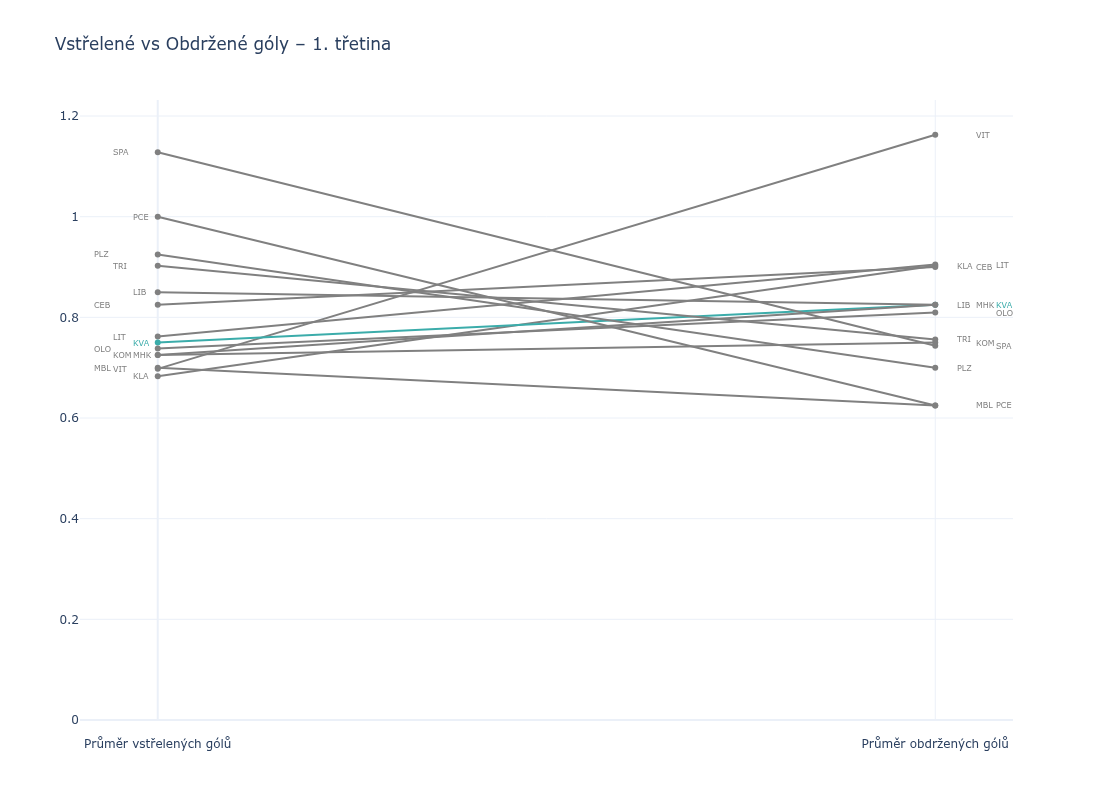

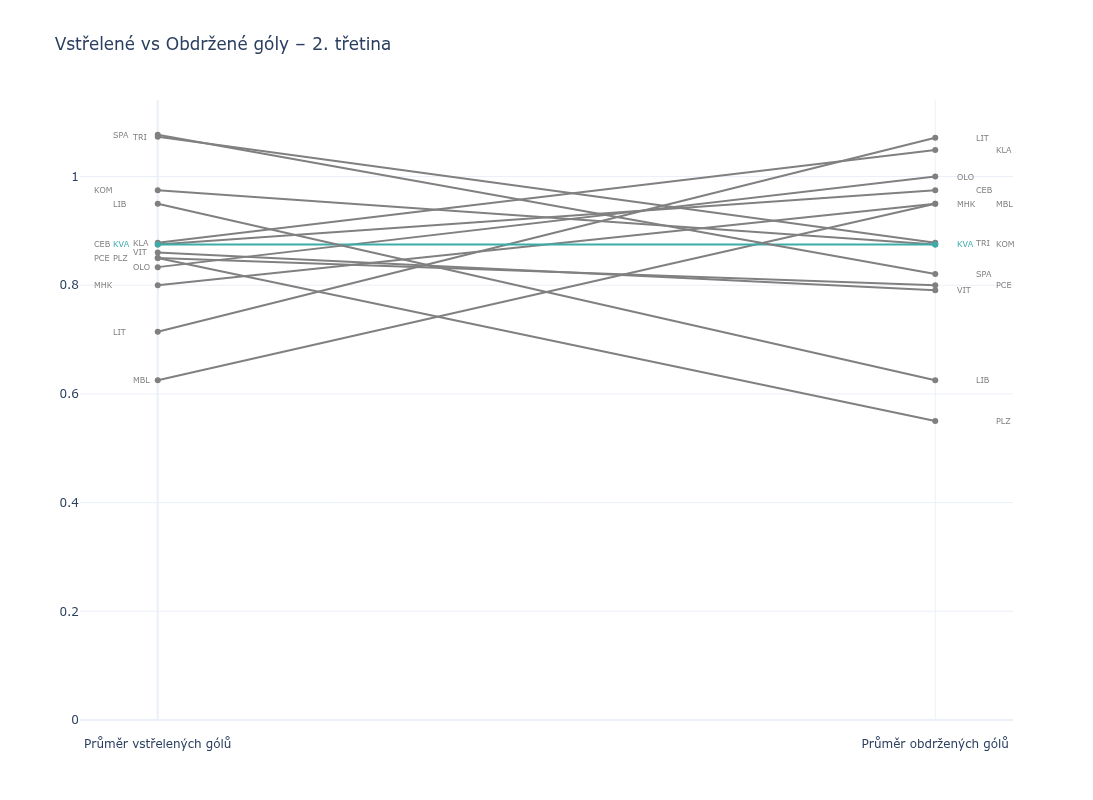

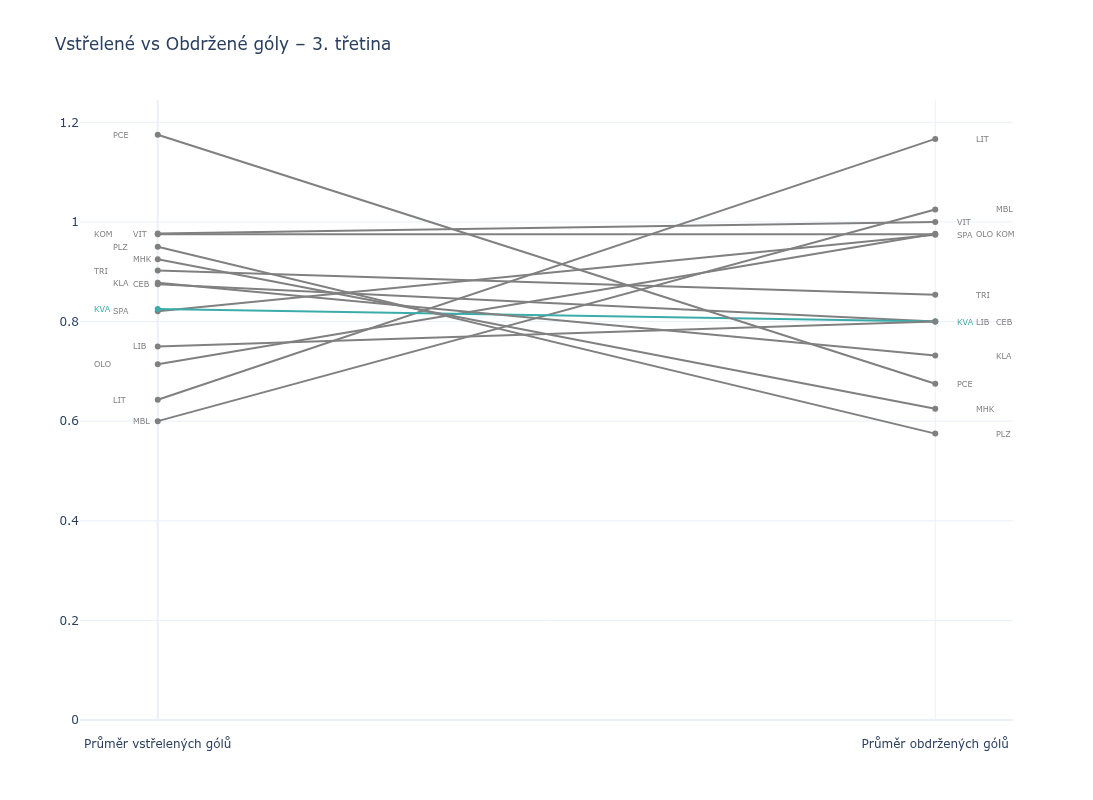

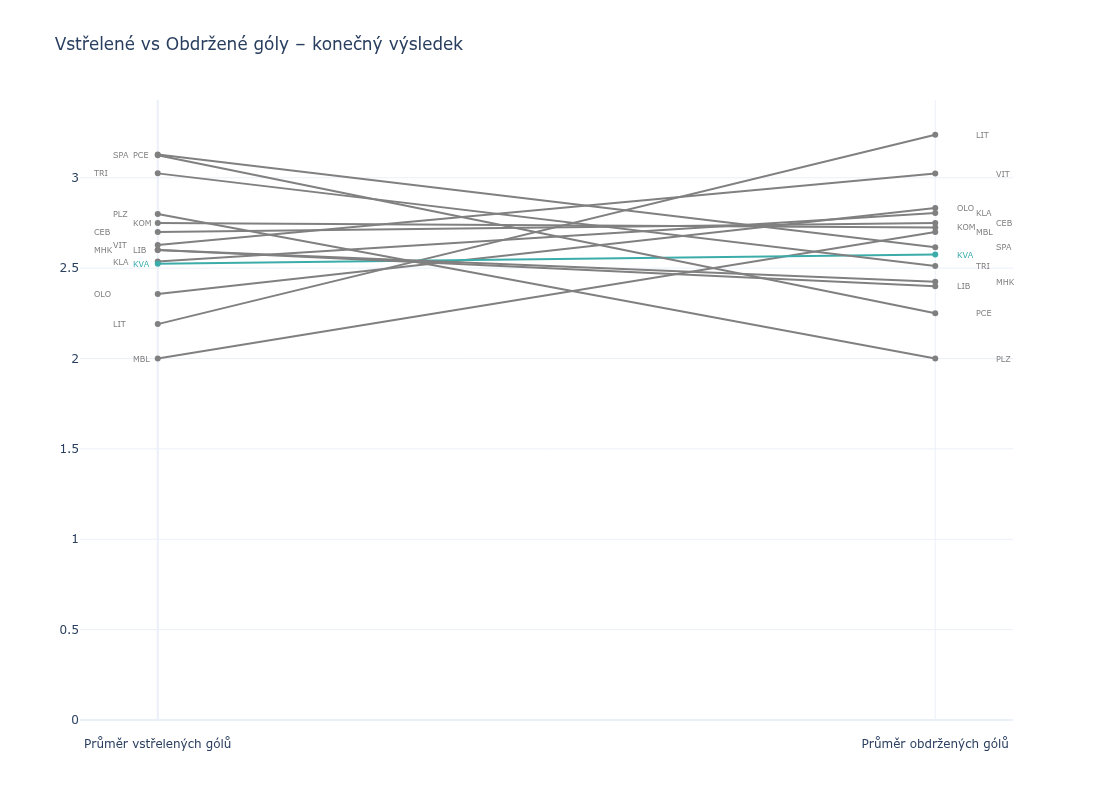

In [16]:
for period in team_period["period"].unique():
    df_period = team_period[team_period["period"] == period]

    offset_r = define_offset(df_period, "gaa", "team")
    offset_l = define_offset(df_period, "gfa", "team")
    actual_label = "konečný výsledek" if period == "F" else f"{period}. třetina"
    
    fig = go.Figure()
    
    for team in offset_r.keys():
        team_data = df_period[df_period["team"] == team]
        color = "rgb(59,172,170)" if team == "KVA" else "gray"
        
        fig.add_trace(go.Scatter(
            x=[0, 1], 
            y=[team_data["gfa"].values[0], team_data["gaa"].values[0]],
            mode="lines+markers",
            name=team,
            line=dict(color=color, width=2, )
        ))
        
        fig.add_annotation(
            x=1.05+offset_r[team],  
            y=team_data["gaa"].values[0],
            text=team,
            showarrow=False,
            xanchor="left",
            font=dict(color=color, size=8)
        )

        fig.add_annotation(
            x=-0.06+offset_l[team],  
            y=team_data["gfa"].values[0],
            text=team,
            showarrow=False,
            xanchor="left",
            font=dict(color=color, size=8)
        )
    
    fig.update_layout(
        title=f"Vstřelené vs Obdržené góly – {actual_label}",
        xaxis=dict(
            tickvals=[0, 1],
            ticktext=["Průměr vstřelených gólů", "Průměr obdržených gólů"],
            range=[-0.1, 1.1],
            ticklabelposition="outside",
            ticklabelstandoff=15 
        ),
        yaxis=dict(
            rangemode="tozero", #dtick=0.1,
                  ),
        height=800,
        showlegend=False
    )
    
    fig.show()

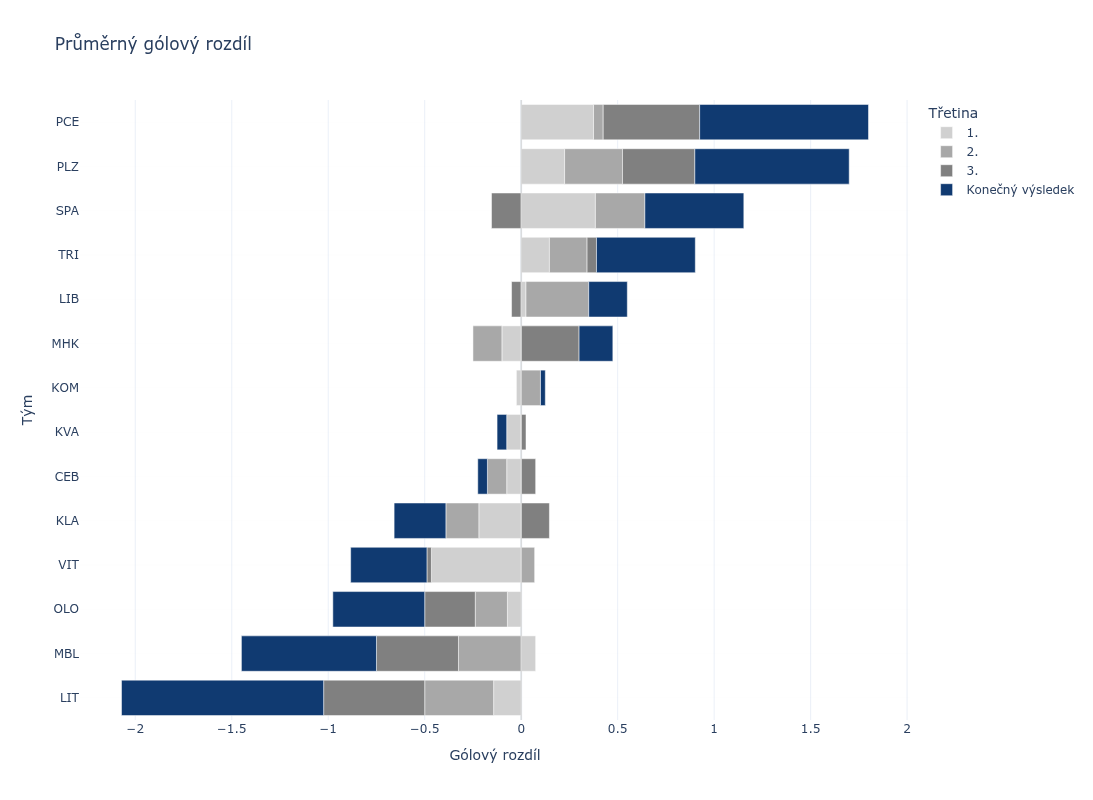

In [35]:
fig = px.bar(
    team_period,
    x="gdiff",
    y="team",
    color="period_label",
    orientation="h",
    title="Průměrný gólový rozdíl",
    color_discrete_map=COLOR_MAP,
    labels={
        "period_label": "Třetina",
        "gdiff": "Gólový rozdíl",
        "team": "Tým",
    },
)

fig.update_layout(
    xaxis_title="Gólový rozdíl",
    yaxis_title="Tým",
    height=800,
)

fig.add_vline(x=0, line_width=1, line_color="lightgray")

order = (
    team_period[team_period["period"] == "F"]
    .sort_values("gdiff")["team"]
)

fig.update_yaxes(
    categoryorder="array", 
    categoryarray=order,
    showgrid=True,
    gridwidth=0.1,
    gridcolor="rgba(0,0,0,0.1)",
                )

fig.show()

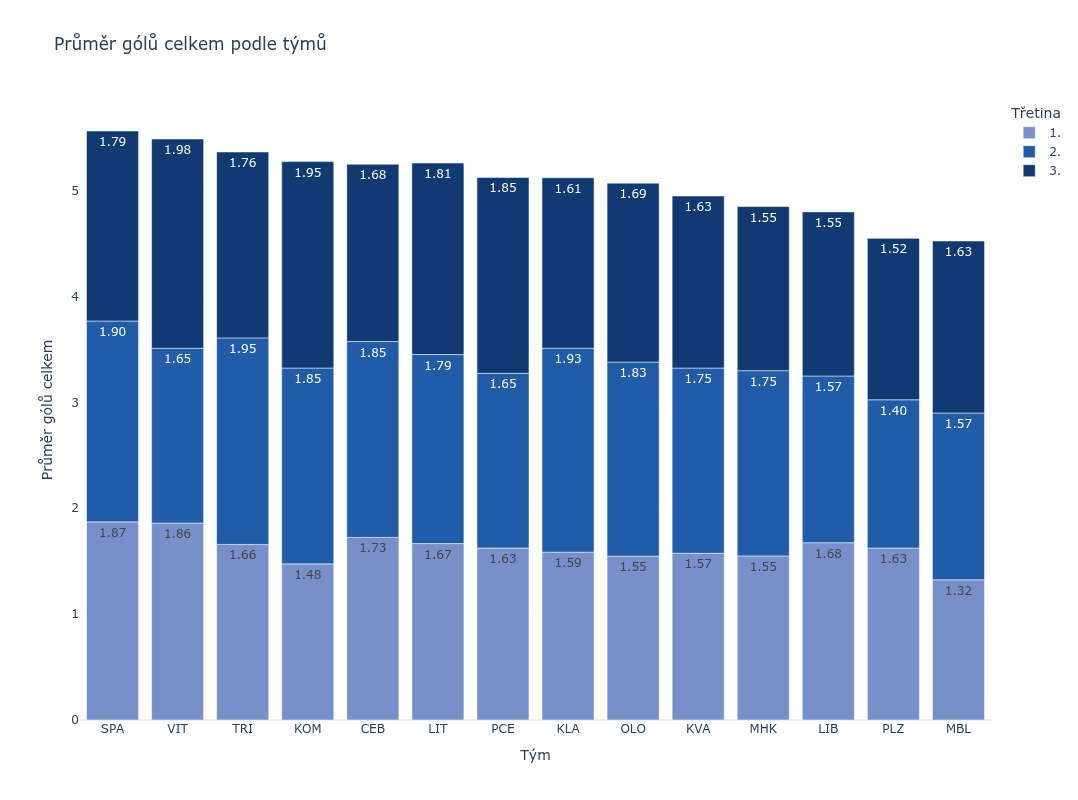

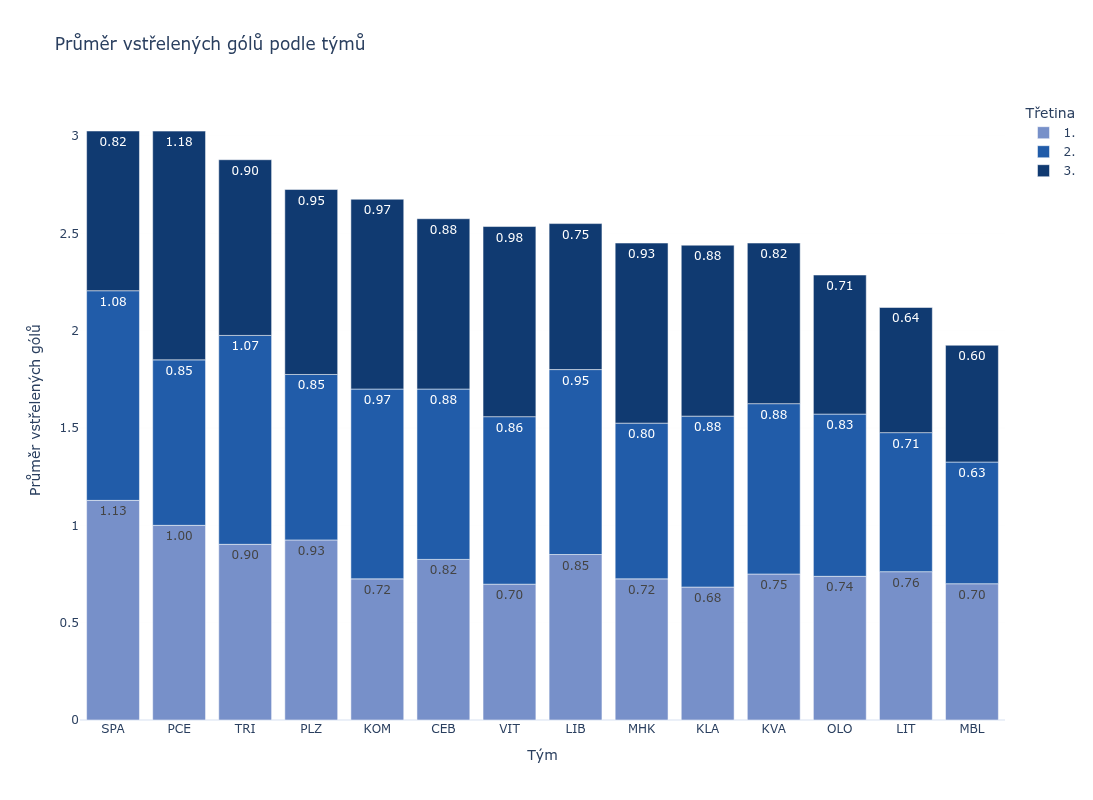

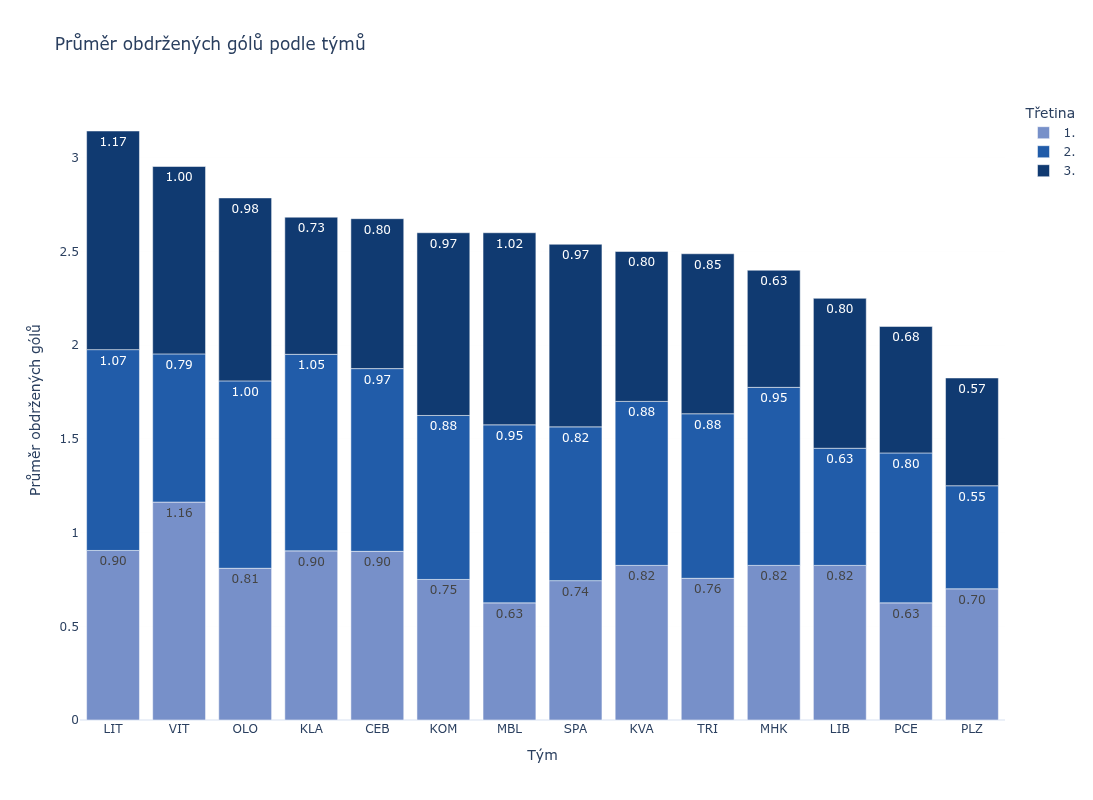

In [74]:
for avg_metric in AVG_LABELS.keys(): 

    fig = px.bar(
        team_period.loc[lambda x: x["period"]!="F"],
        x="team",
        y=avg_metric,
        color="period_label",
        title=f"{AVG_LABELS[avg_metric]} podle týmů",
        color_discrete_map=COLOR_MAP_SHORT,
        text=avg_metric,
        labels={
            "team": "Tým",
            avg_metric: AVG_LABELS[avg_metric],
            "period_label": "Třetina",
        },
    )
    
    order = (team_period.loc[lambda x: x["period"] == "F"].sort_values(avg_metric, ascending=False)["team"])
    
    fig.update_traces(
        texttemplate="%{text:.2f}",   
        textposition="inside",
    )
    
    fig.update_layout(
        height=800,
        xaxis=dict(
            categoryorder="array",
            categoryarray=order
        ),
        yaxis_title=AVG_LABELS[avg_metric],
    )
    
    fig.update_yaxes(
        categoryorder="array", 
        categoryarray=order,
        showgrid=True,
        gridwidth=0.1,
        gridcolor="rgba(0,0,0,0.1)",
                    )
    
    fig.show()

In [18]:
win_goals = (
    tables_df
        .loc[lambda x: x["period"]=="F"]
        .loc[lambda x: x["result"]=="V"]
    .groupby(["team"], as_index=False)
    .agg(
        avg_goal_diff=("goal_diff", "mean"), 
        avg_goal=("gf", "mean"),
        avg_goal_a=("ga", "mean"),
        matches=("points", "count"), 
        points=("points", "sum"),         
    )
    .sort_values("points", ascending=False)
    .reset_index(drop=True)
    .assign(
        team_label=(
            lambda x: x["team"]+ " zápasů: "+x["matches"].astype(str)+ " | bodů: "+x["points"].astype(str)
        )
    )
)

In [19]:
win_goals.head()

,team,avg_goal_diff,avg_goal,avg_goal_a,matches,points,team_label
0,PCE,2.619048,4.190476,1.571429,21,63,PCE zápasů: 21 | bodů: 63
1,KVA,1.842105,3.105263,1.263158,19,57,KVA zápasů: 19 | bodů: 57
2,PLZ,2.684211,3.736842,1.052632,19,57,PLZ zápasů: 19 | bodů: 57
3,TRI,2.368421,4.052632,1.684211,19,57,TRI zápasů: 19 | bodů: 57
4,LIB,2.111111,3.611111,1.500000,18,54,LIB zápasů: 18 | bodů: 54


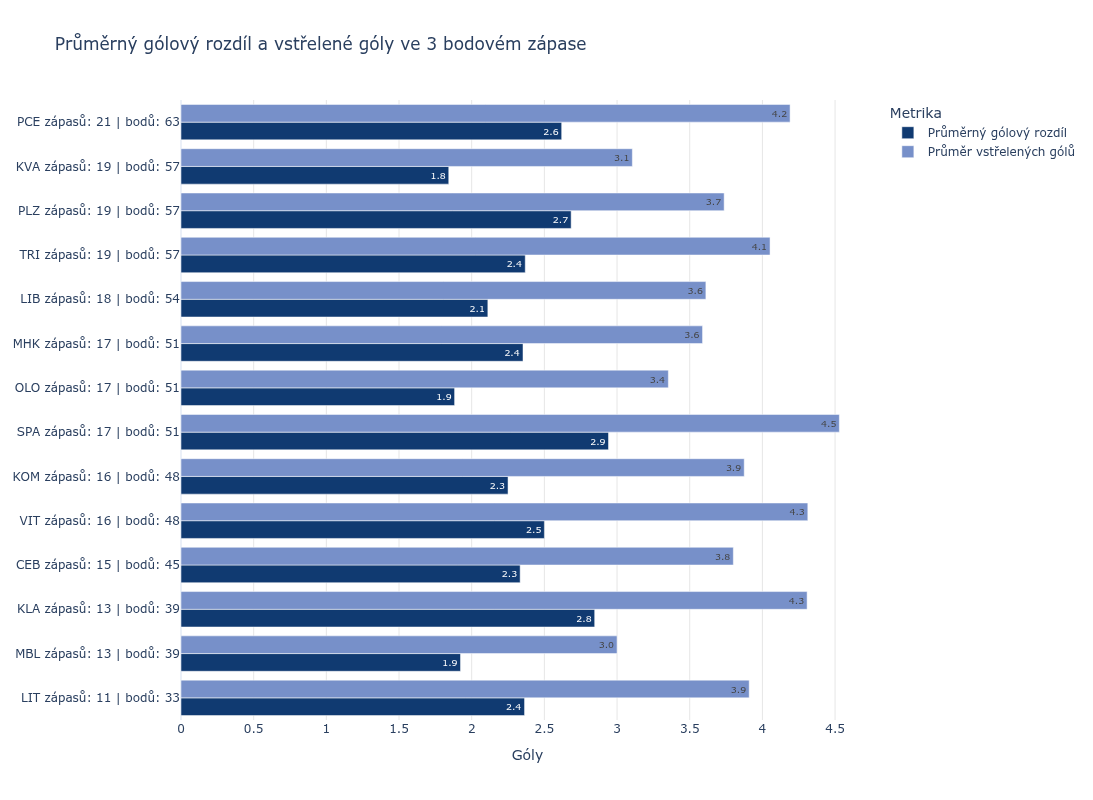

In [20]:
y_order = win_goals["team_label"].tolist()[::-1]

fig = go.Figure()

fig.add_bar(
    x=win_goals["avg_goal_diff"],
    y=win_goals["team_label"],
    orientation="h",
    name="Průměrný gólový rozdíl",
    marker_color="#103A71",
    text=win_goals["avg_goal_diff"],
    texttemplate="%{text:.1f}",
    textposition="inside",
)

fig.add_bar(
    x=win_goals["avg_goal"],
    y=win_goals["team_label"],
    orientation="h",
    name="Průměr vstřelených gólů",
    marker_color="#7790C9",
    text=win_goals["avg_goal"],
    texttemplate="%{text:.1f}",
    textposition="inside",
)

fig.update_layout(
    title="Průměrný gólový rozdíl a vstřelené góly ve 3 bodovém zápase",
    barmode="group",
    height=800,
    xaxis_title="Góly",
    yaxis=dict(
        categoryorder="array",
        categoryarray=y_order, 
    ),
    xaxis=dict(
        dtick=0.5,
    ),
    legend_title="Metrika",
)

fig.update_xaxes(showgrid=True, gridcolor="rgba(0,0,0,0.1)")

fig.show()

In [21]:
losing_points = (
    tables_df
        .assign(
            lost_points=lambda x: x["points"] - 3, 
            ga_per_lost_point=lambda x: x["ga"] / x["lost_points"], 
        )
        .loc[lambda x: x["period"]=="F"]
        .loc[lambda x: x["result"]!="V"]
        .groupby(["team"], as_index=False)
        .agg(
            avg_goal_diff=("goal_diff", "mean"), 
            avg_goal=("gf", "mean"),
            avg_goal_a=("ga", "mean"),
            matches=("points", "count"), 
            lost_points=("lost_points", "sum"),     
            ga_per_lost_point=("ga_per_lost_point", "mean"),
        )
        .assign(
            avg_goal_a=lambda x: x["avg_goal_a"]*-1,
        )
        .sort_values("lost_points", ascending=False)
        .reset_index(drop=True)
        .assign(
            team_label=(
                lambda x: x["team"]+ " zápasů: "+x["matches"].astype(str)+ " | bodů: "+x["lost_points"].astype(str)
            ), 
        )
)

In [22]:
losing_points.head()

,team,avg_goal_diff,avg_goal,avg_goal_a,matches,lost_points,ga_per_lost_point,team_label
0,PCE,-1.052632,1.947368,-3.000000,19,-43,-1.333333,PCE zápasů: 19 | bodů: -43
1,PLZ,-0.904762,1.952381,-2.857143,21,-50,-1.293651,PLZ zápasů: 21 | bodů: -50
2,TRI,-1.090909,2.136364,-3.227273,22,-53,-1.416667,TRI zápasů: 22 | bodů: -53
3,KVA,-1.761905,2.000000,-3.761905,21,-54,-1.603175,KVA zápasů: 21 | bodů: -54
4,SPA,-1.363636,2.045455,-3.409091,22,-55,-1.530303,SPA zápasů: 22 | bodů: -55


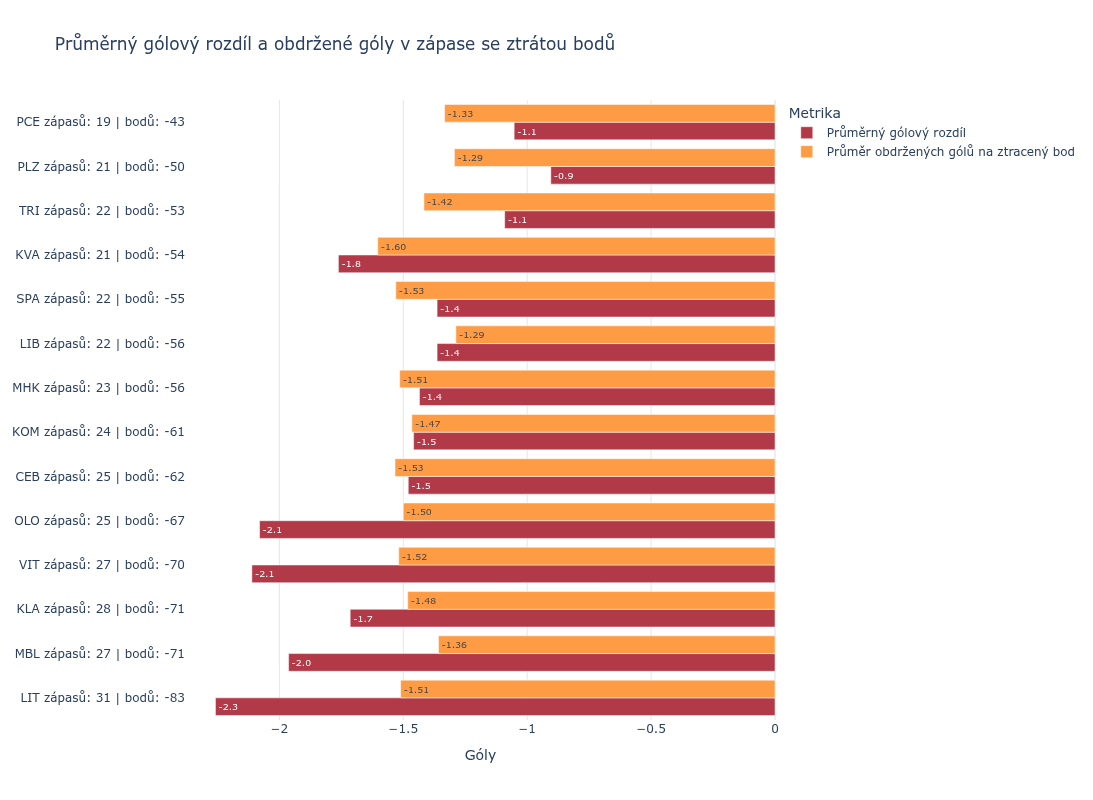

In [23]:
y_order = losing_points["team_label"].tolist()[::-1]

fig = go.Figure()

fig.add_bar(
    x=losing_points["avg_goal_diff"],
    y=losing_points["team_label"],
    orientation="h",
    name="Průměrný gólový rozdíl",
    marker_color="#B23A48",
    text=losing_points["avg_goal_diff"],
    texttemplate="%{text:.1f}",
    textposition="inside",
)

fig.add_bar(
    x=losing_points["ga_per_lost_point"],
    y=losing_points["team_label"],
    orientation="h",
    name="Průměr obdržených gólů na ztracený bod",
    marker_color="#FE9B45",
    text=losing_points["ga_per_lost_point"],
    texttemplate="%{text:.2f}",
    textposition="inside",
)

fig.update_layout(
    title="Průměrný gólový rozdíl a obdržené góly v zápase se ztrátou bodů",
    barmode="group",
    height=800,
    xaxis_title="Góly",
    yaxis=dict(
        categoryorder="array",
        categoryarray=y_order
    ),
    legend_title="Metrika",
)

fig.update_xaxes(showgrid=True, gridcolor="rgba(0,0,0,0.1)")

fig.show()

In [65]:
team_period_field = (
    tables_df
        .loc[lambda x: x["period"].isin([1,2,3, "F"])]
        .assign(g_total=lambda x: x["gf"] + x["ga"])
        .groupby(["team", "period", "field"], as_index=False)
        .agg(
            gf=("gf", "sum"), 
            gfa=("gf", "mean"), 
            ga=("ga", "sum"), 
            gaa=("ga", "mean"), 
            gat=("g_total", "mean"),
            gdiff=("goal_diff", "mean")
        )
)
team_period_field["period_label"] = team_period_field["period"].map(PERIOD_MAP)

In [66]:
team_period_field.head()

,team,period,field,gf,gfa,ga,gaa,gat,gdiff,period_label
0,CEB,1,D,16,0.80,14,0.70,1.50,0.10,1.
1,CEB,1,V,17,0.85,22,1.10,1.95,-0.25,1.
2,CEB,2,D,16,0.80,15,0.75,1.55,0.05,2.
3,CEB,2,V,19,0.95,24,1.20,2.15,-0.25,2.
4,CEB,3,D,20,1.00,13,0.65,1.65,0.35,3.


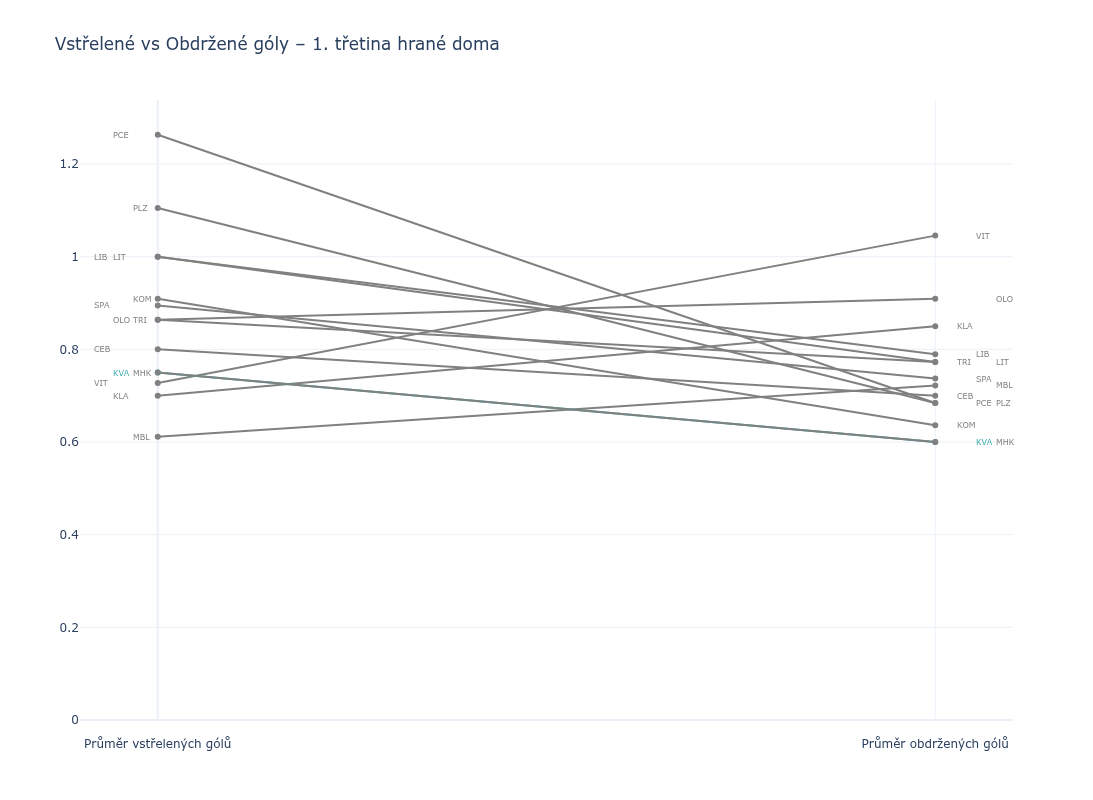

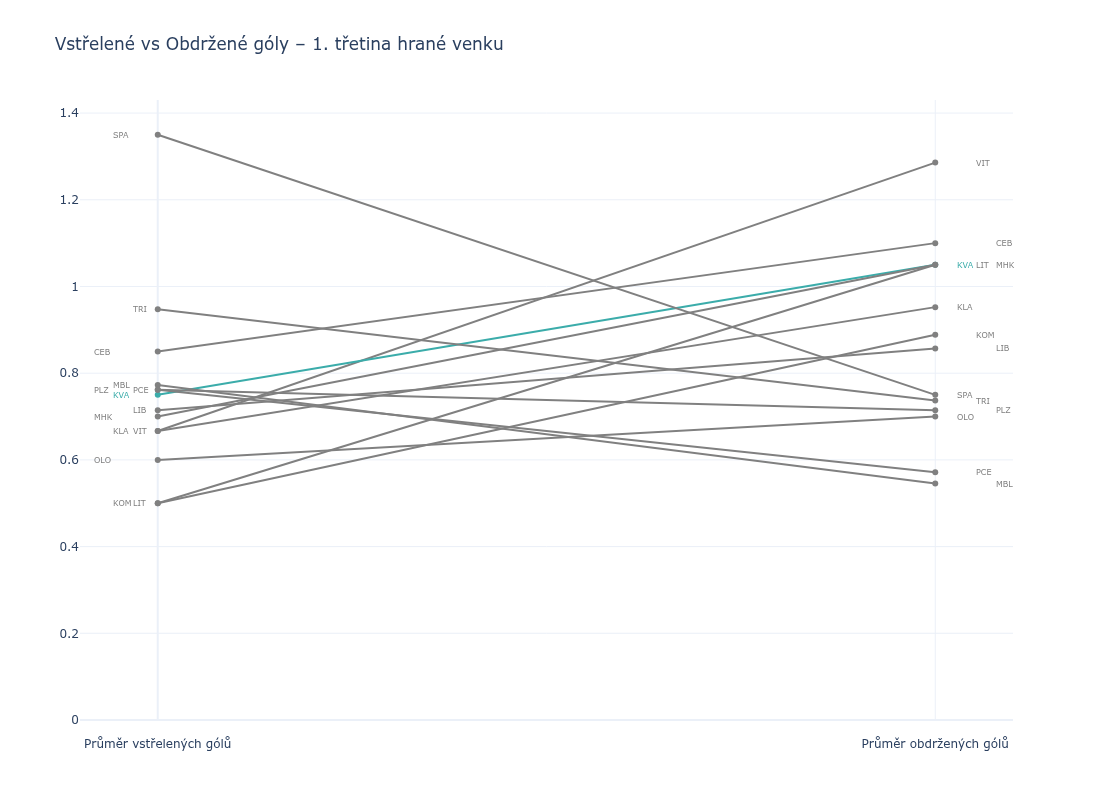

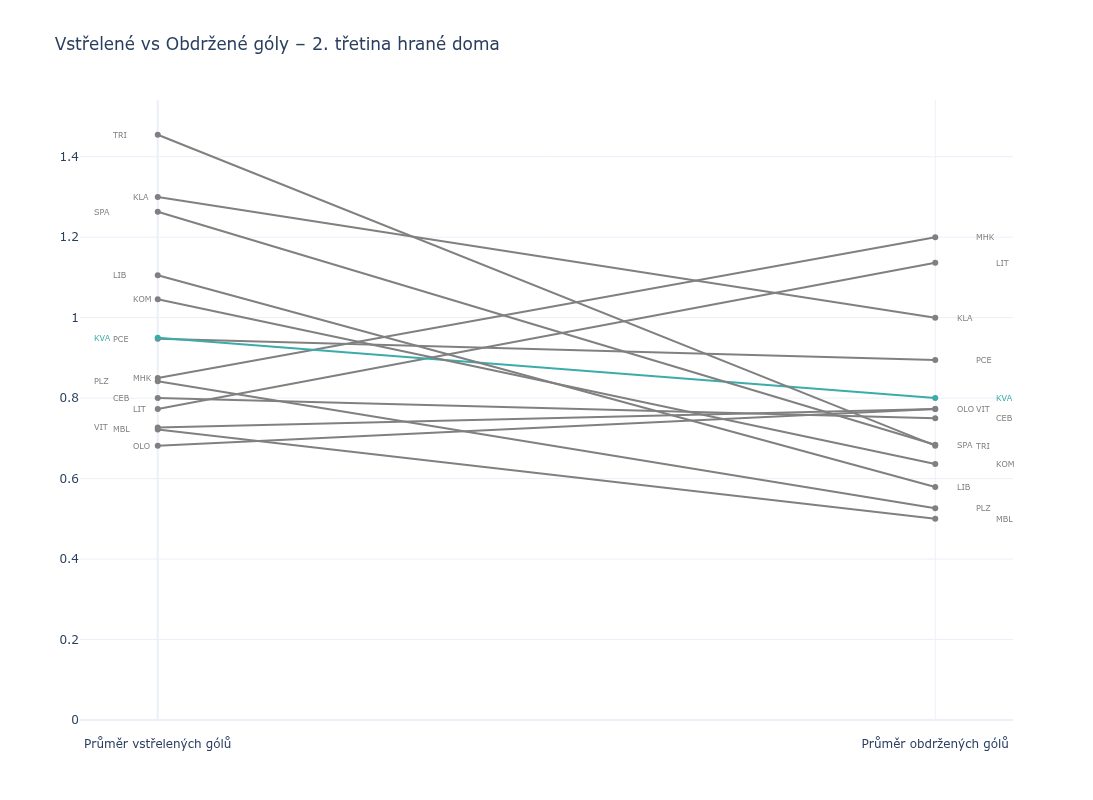

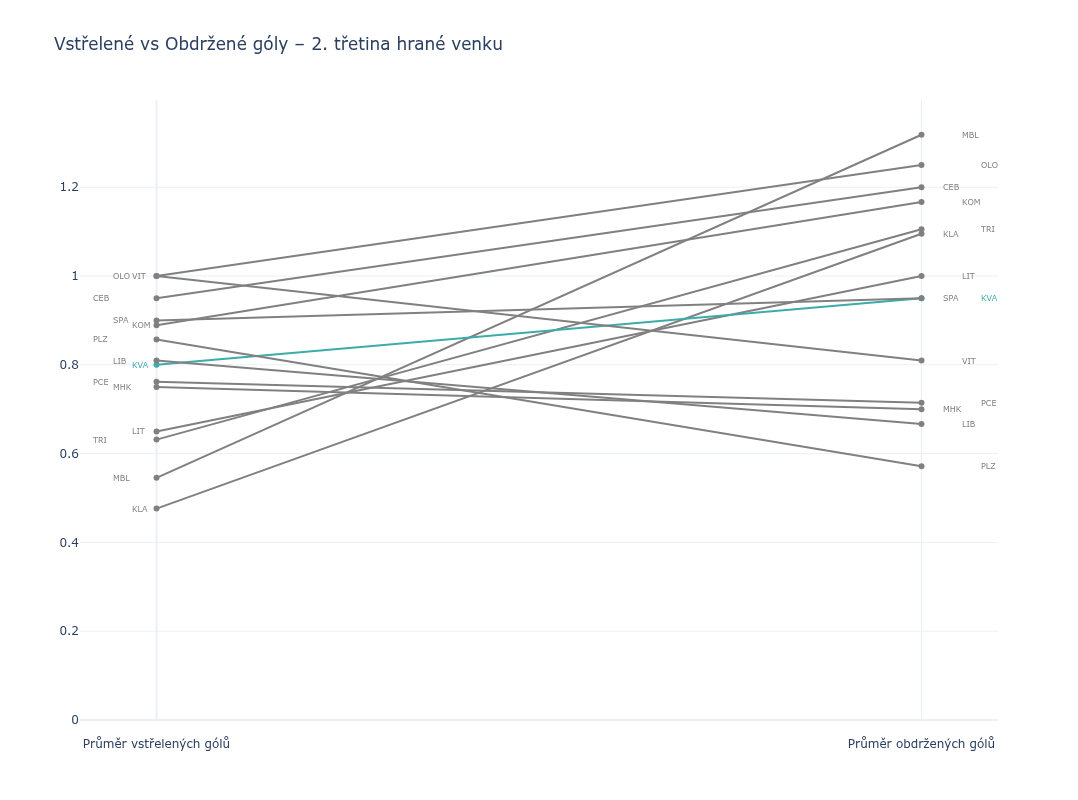

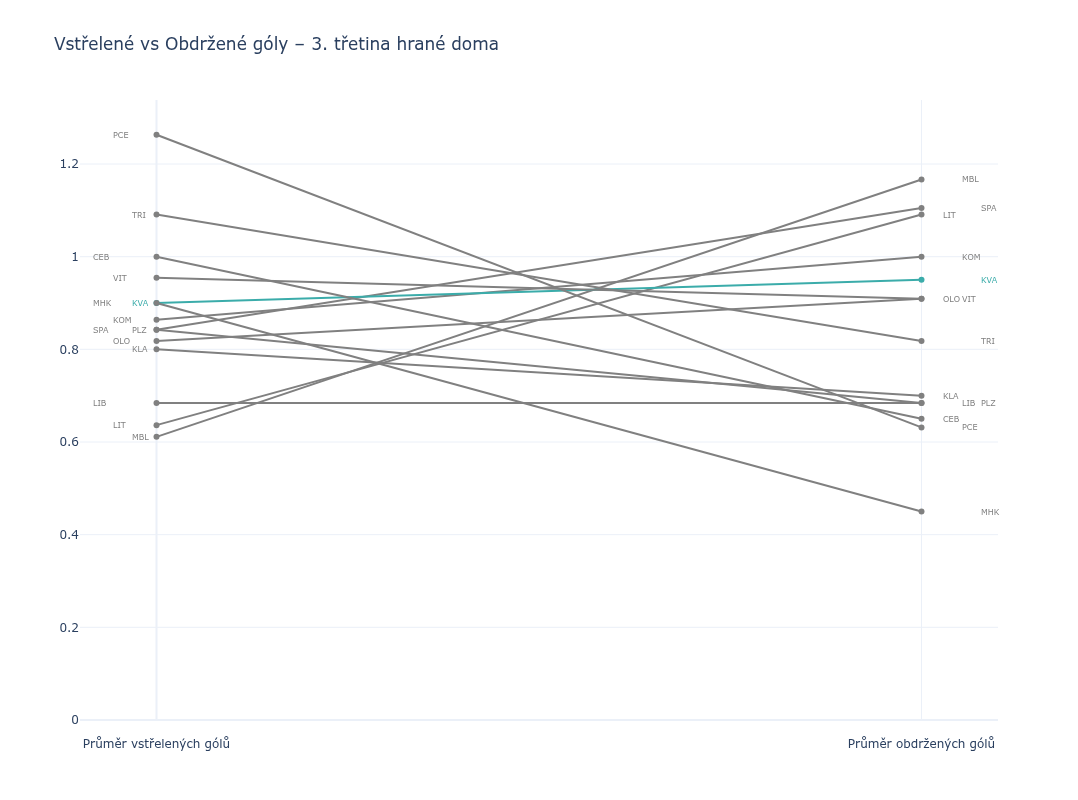

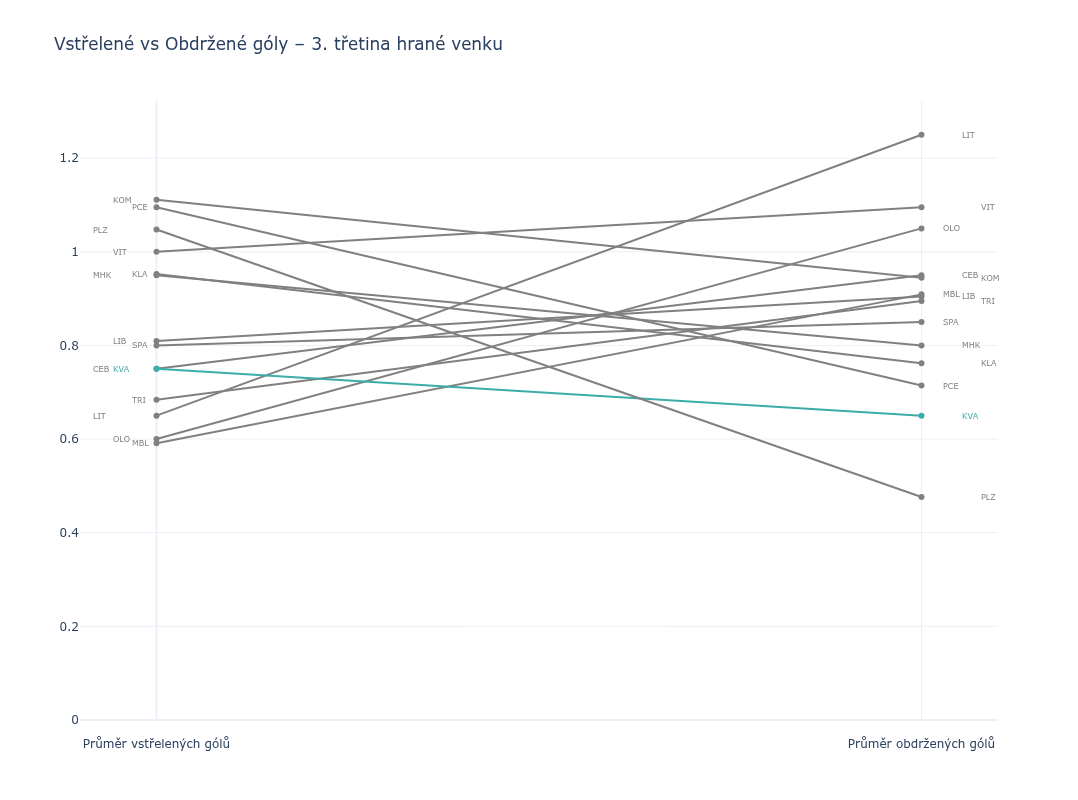

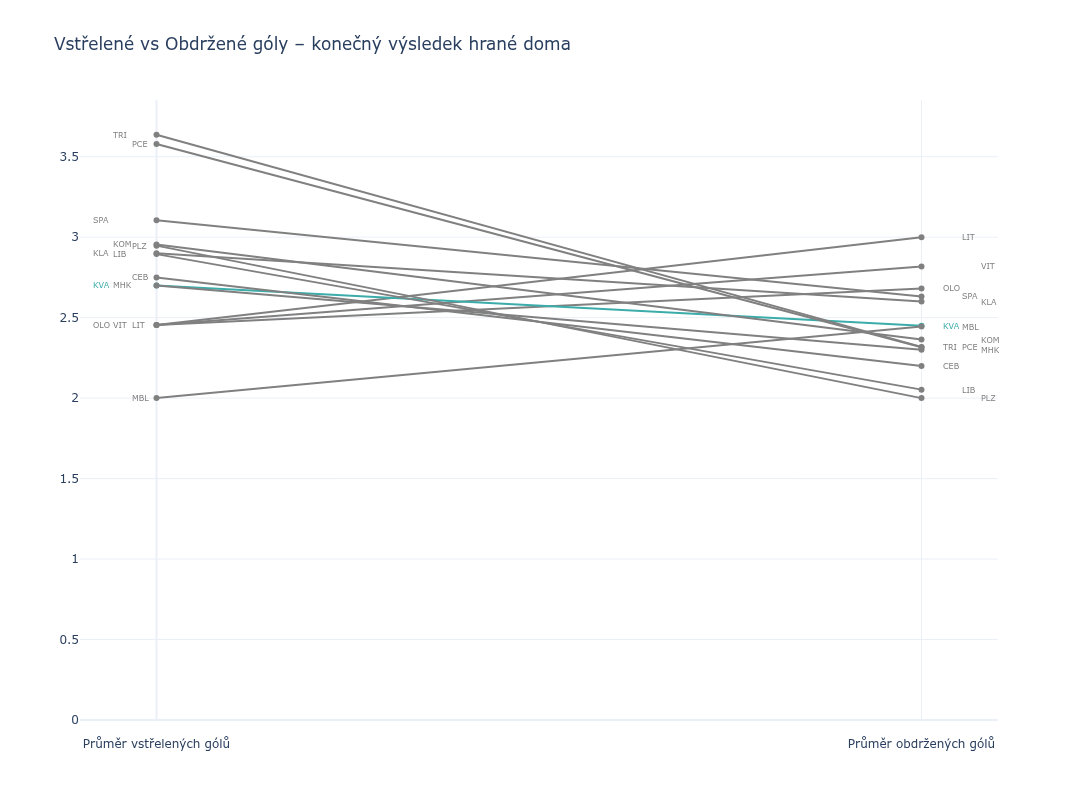

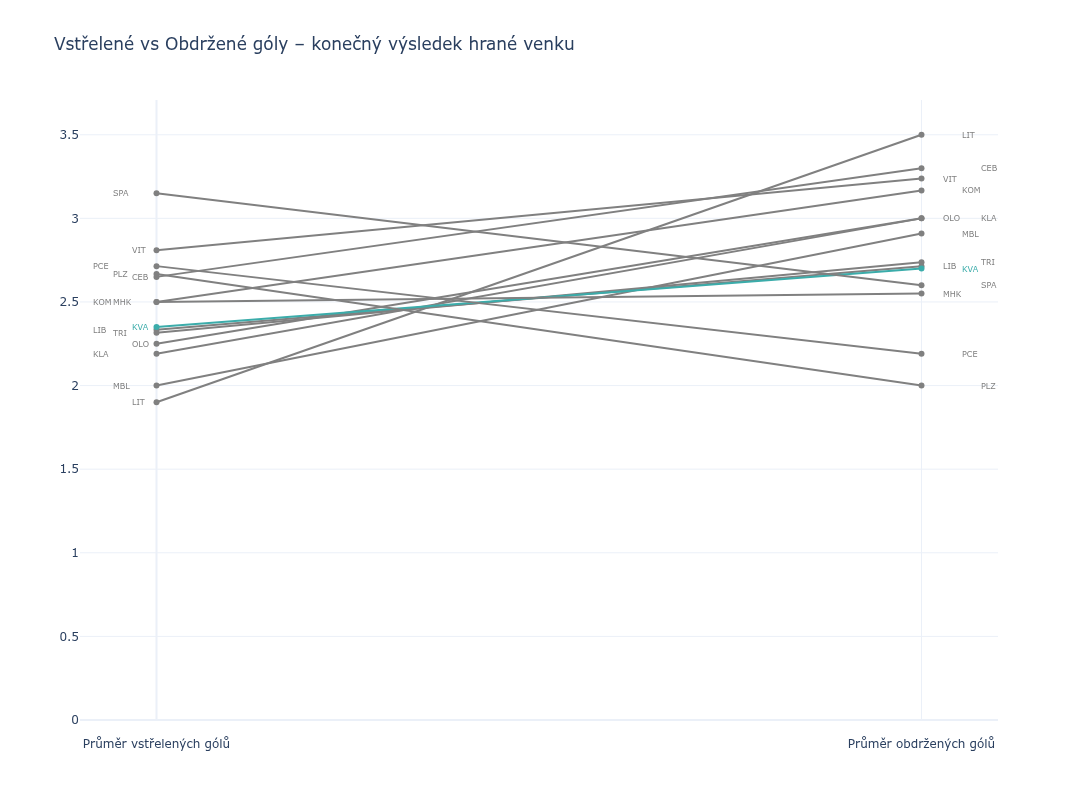

In [26]:
for period, field in product(
        team_period_field["period"].unique(),
        team_period_field["field"].unique()
    ):
    df_period = team_period_field.loc[lambda x: x["period"] == period].loc[lambda x: x["field"] == field]

    offset_r = define_offset(df_period, "gaa", "team")
    offset_l = define_offset(df_period, "gfa", "team")
    period_label = "konečný výsledek" if period == "F" else f"{period}. třetina"
    field_label = "venku" if field == "V" else "doma"
    
    fig = go.Figure()
    
    for team in offset_r.keys():
        team_data = df_period[df_period["team"] == team]
        color = "rgb(59,172,170)" if team == "KVA" else "gray"
        
        fig.add_trace(go.Scatter(
            x=[0, 1], 
            y=[team_data["gfa"].values[0], team_data["gaa"].values[0]],
            mode="lines+markers",
            name=team,
            line=dict(color=color, width=2, )
        ))
        
        fig.add_annotation(
            x=1.05+offset_r[team],  
            y=team_data["gaa"].values[0],
            text=team,
            showarrow=False,
            xanchor="left",
            font=dict(color=color, size=8)
        )

        fig.add_annotation(
            x=-0.06+offset_l[team],  
            y=team_data["gfa"].values[0],
            text=team,
            showarrow=False,
            xanchor="left",
            font=dict(color=color, size=8)
        )
    
    fig.update_layout(
        title=f"Vstřelené vs Obdržené góly – {period_label} hrané {field_label}",
        xaxis=dict(
            tickvals=[0, 1],
            ticktext=["Průměr vstřelených gólů", "Průměr obdržených gólů"],
            range=[-0.1, 1.1],
            ticklabelposition="outside",
            ticklabelstandoff=15 
        ),
        yaxis=dict(
            rangemode="tozero", #dtick=0.1,
                  ),
        height=800,
        showlegend=False
    )
    
    fig.show()

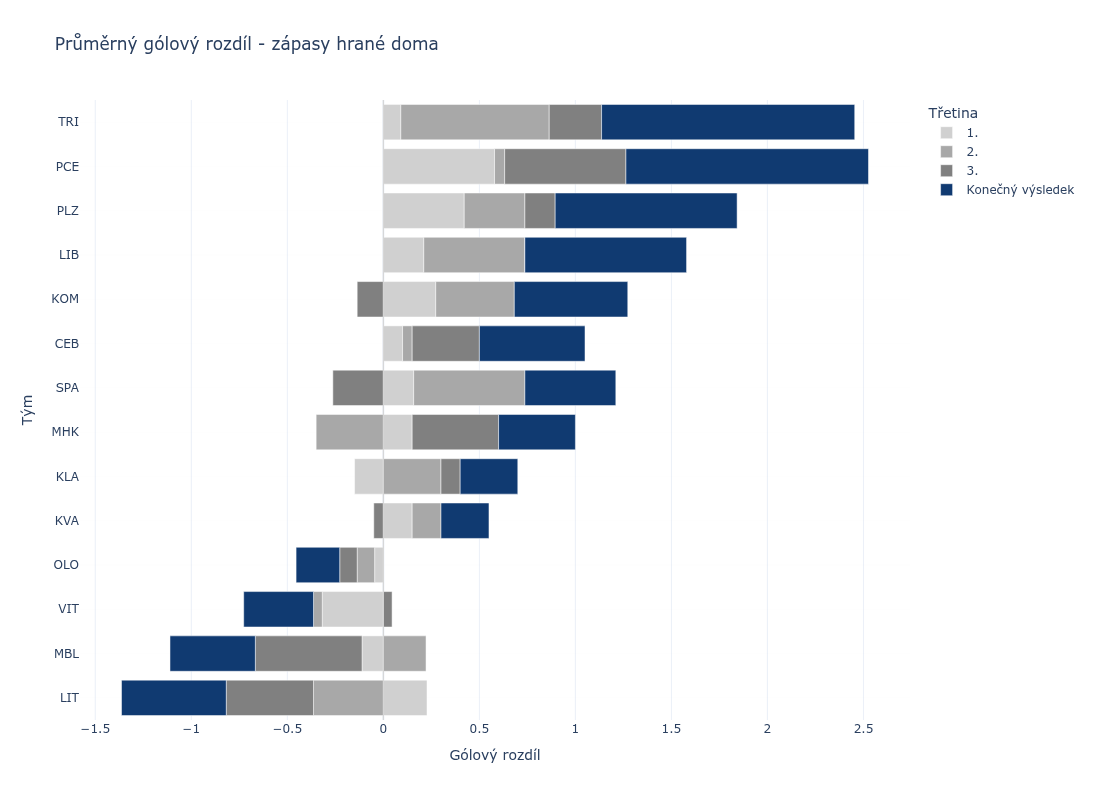

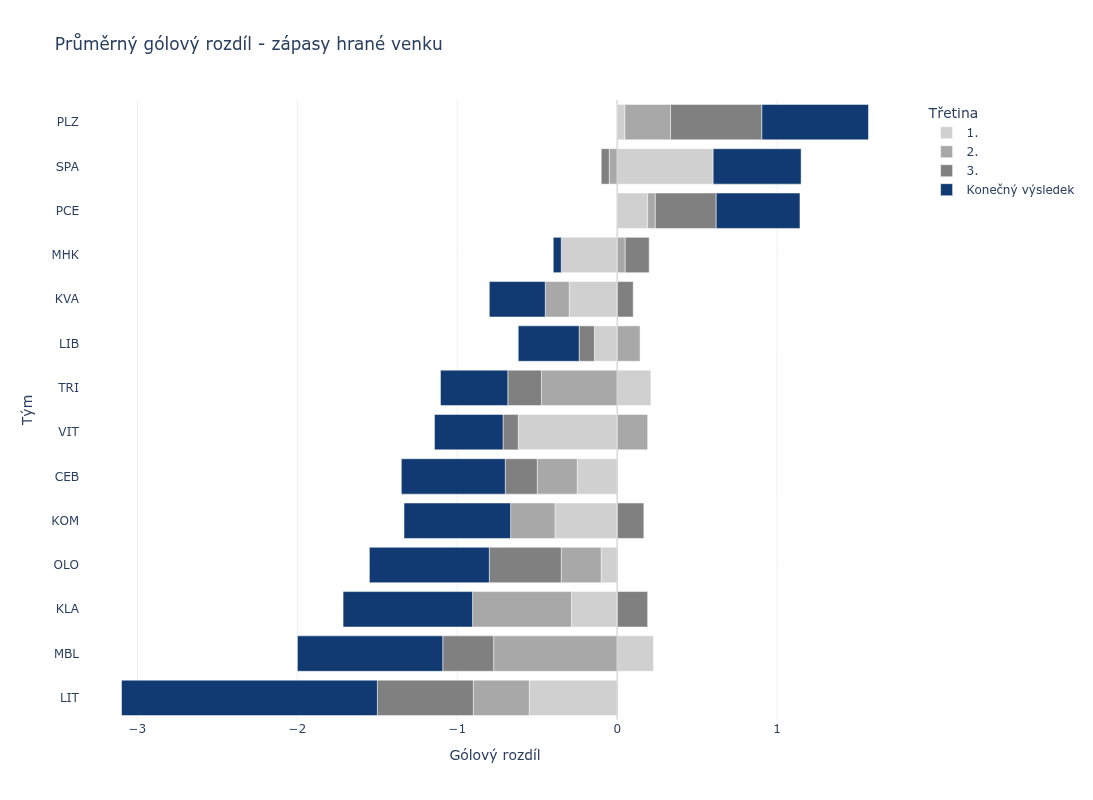

In [27]:
for field in team_period_field["field"].unique(): 
    team_df = team_period_field.loc[lambda x: x["field"]==field]
    fig = px.bar(
        team_df,
        x="gdiff",
        y="team",
        color="period_label",
        orientation="h",
        title=f"Průměrný gólový rozdíl - zápasy hrané {'venku' if field == 'V' else 'doma'}",
        color_discrete_map=COLOR_MAP,
        labels={
            "period_label": "Třetina",
            "gdiff": "Gólový rozdíl",
            "team": "Tým",
        },
    )
    
    fig.update_layout(
        xaxis_title="Gólový rozdíl",
        yaxis_title="Tým",
        height=800,
    )
    
    fig.add_vline(x=0, line_width=1, line_color="lightgray")
    
    order = (
        team_df.loc[lambda x: x["period"] == "F"]
        .sort_values("gdiff")["team"]
    )
    
    fig.update_yaxes(
        categoryorder="array", 
        categoryarray=order,
        showgrid=True,
        gridwidth=0.1,
        gridcolor="rgba(0,0,0,0.1)",
                    )
    
    fig.show()

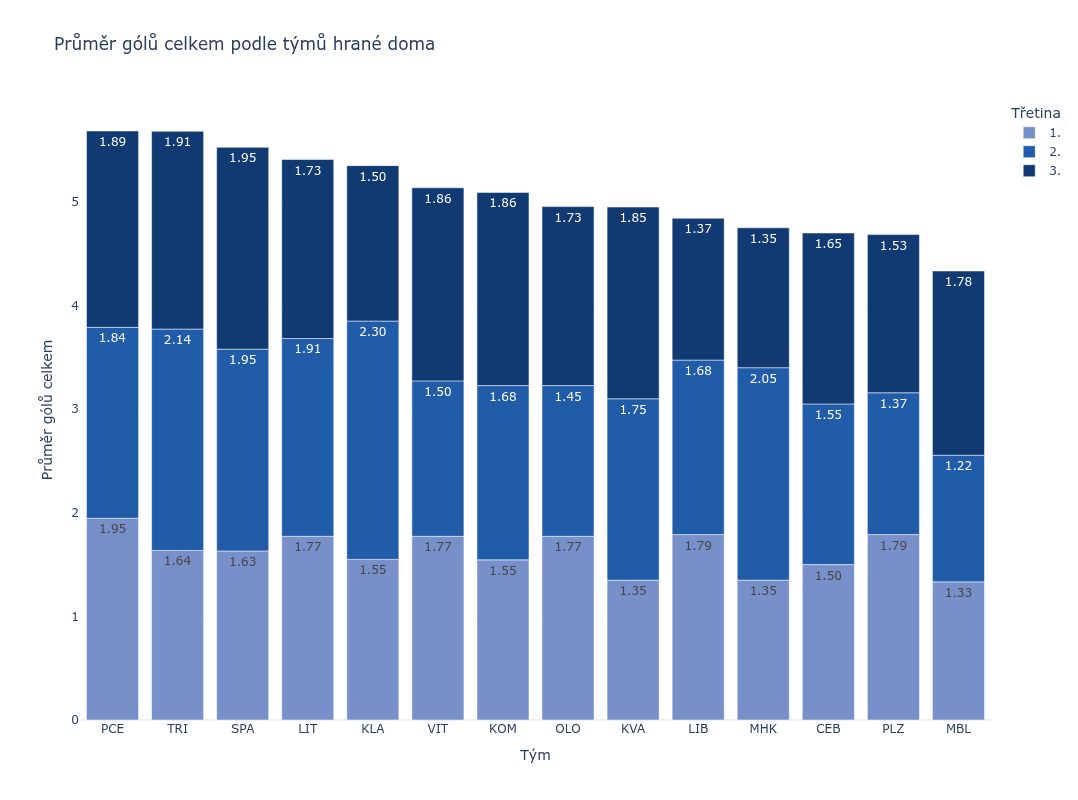

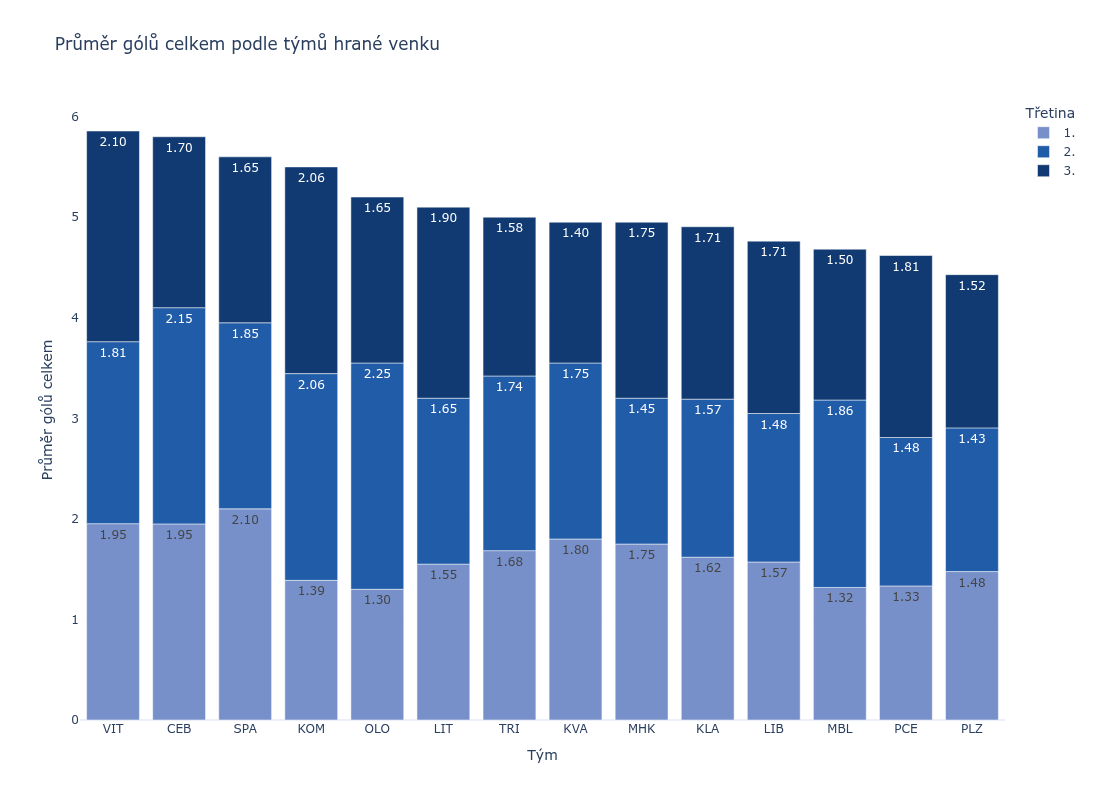

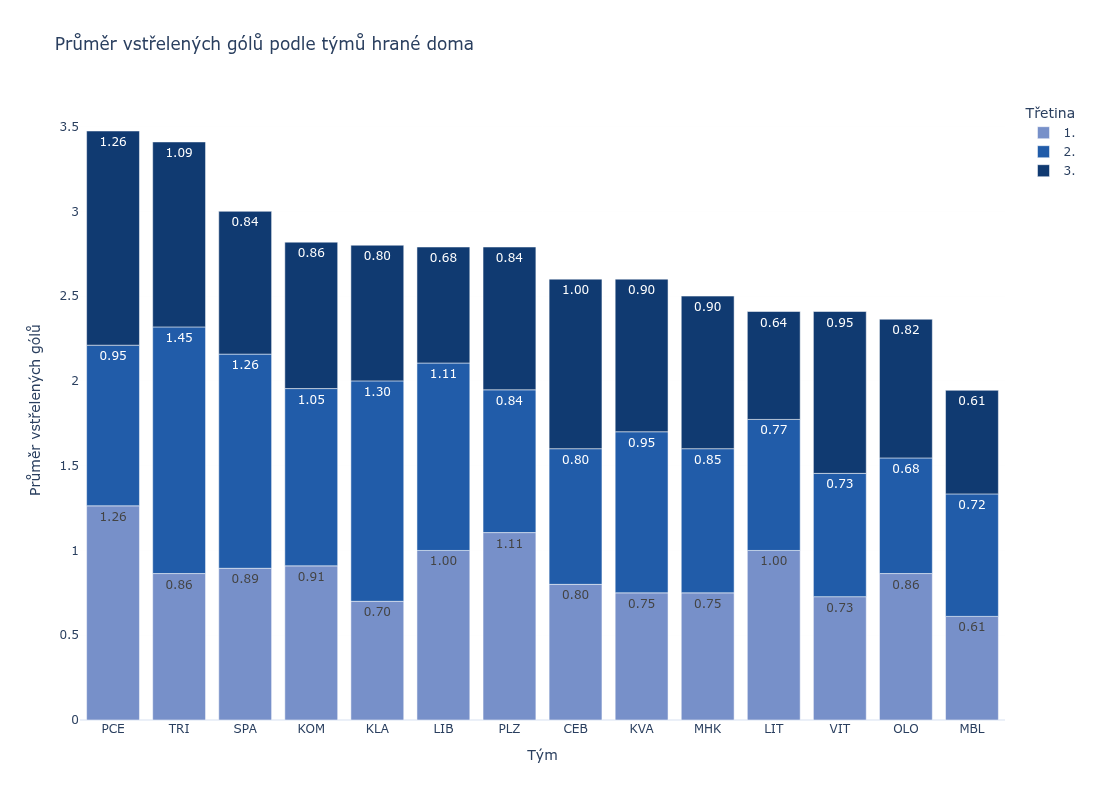

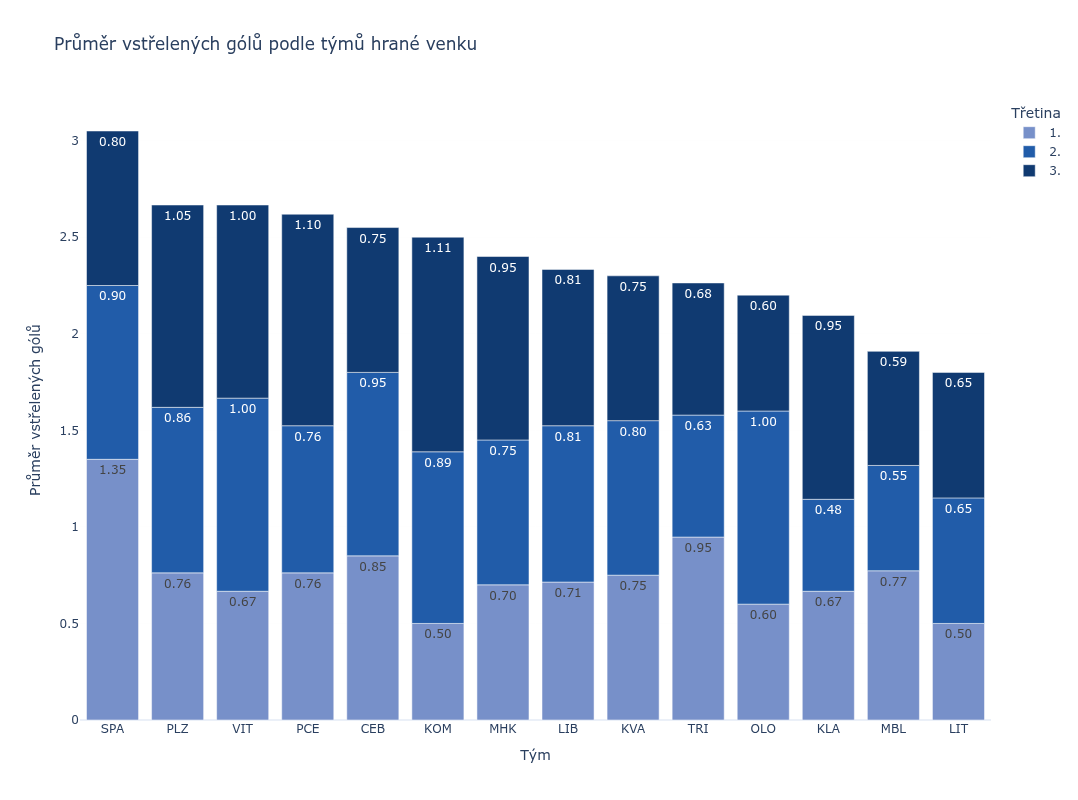

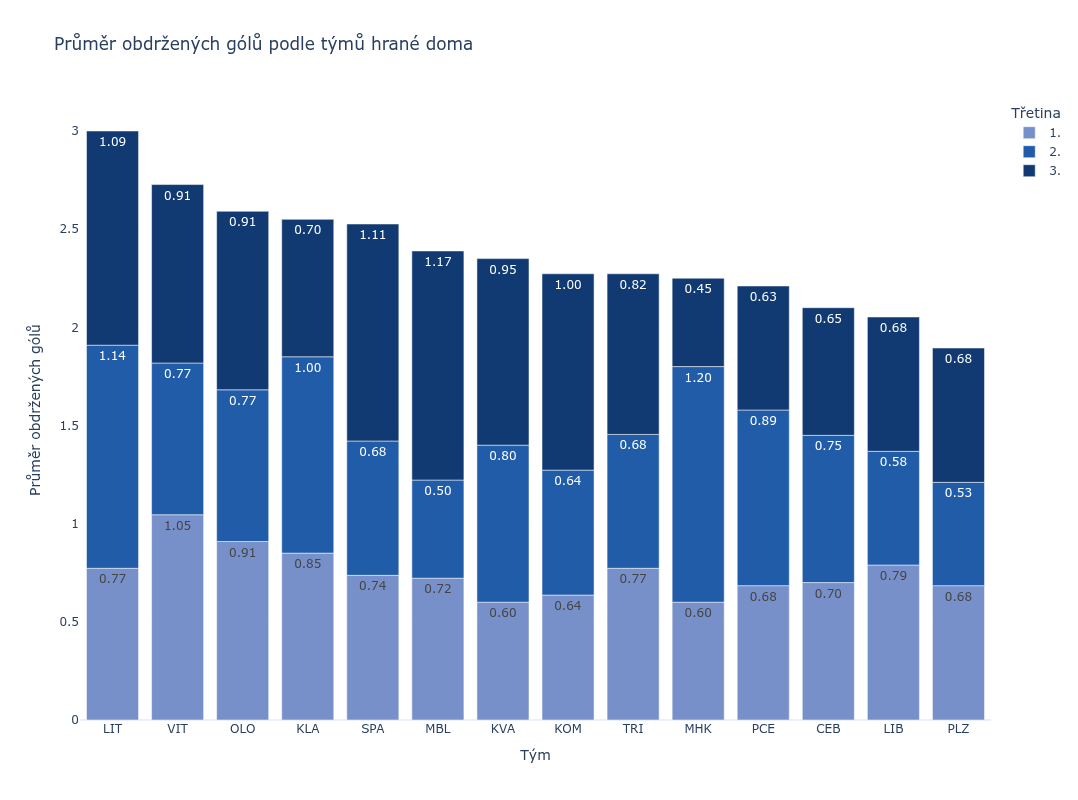

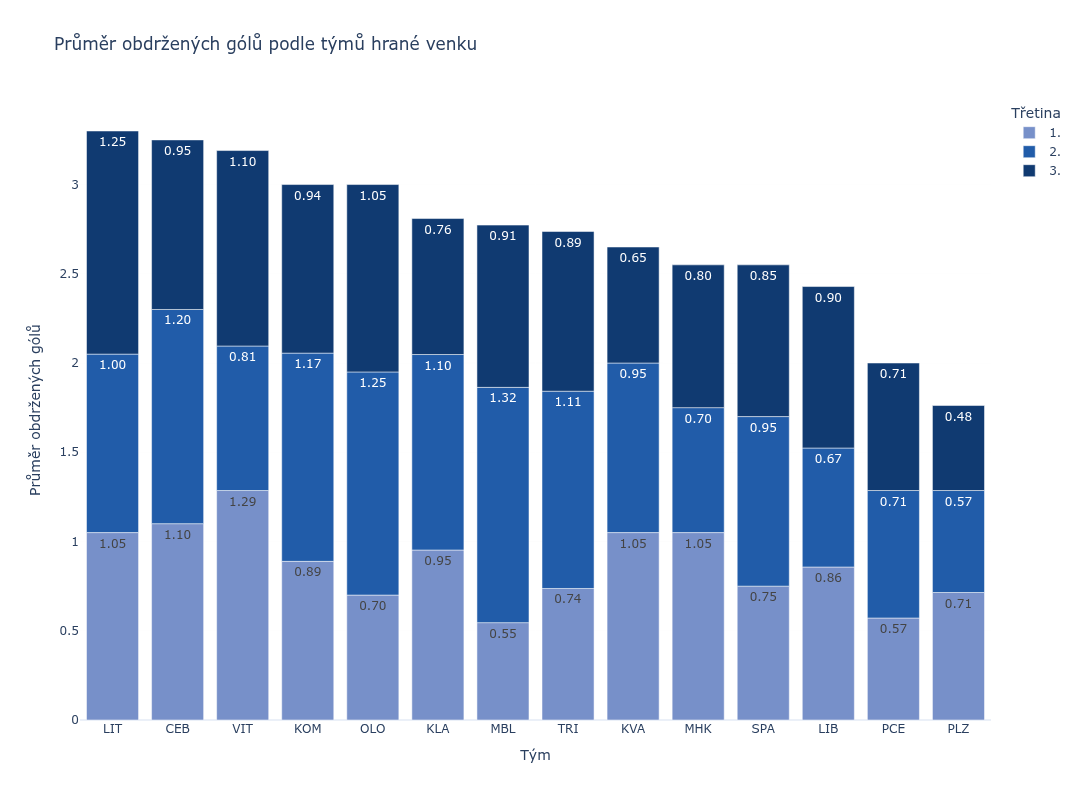

In [91]:
for avg_metric, field in product(
        AVG_LABELS.keys(),
        team_period_field["field"].unique()
    ):
    df_period = team_period_field.loc[lambda x: x["field"] == field].loc[lambda x: x["period"]!="F"].reset_index(drop=True)
    field_label = "venku" if field == "V" else "doma"

    fig = px.bar(
        df_period.loc[lambda x: x["period"]!="F"],
        x="team",
        y=avg_metric,
        color="period_label",
        title=f"{AVG_LABELS[avg_metric]} podle týmů hrané {field_label}",
        color_discrete_map=COLOR_MAP_SHORT,
        text=avg_metric,
        labels={
            "team": "Tým",
            avg_metric: AVG_LABELS[avg_metric],
            "period_label": "Třetina",
        },
    )
    
    order =(
        df_period.groupby("team", as_index=False)
        .agg(metric_sort=(avg_metric, "sum"))
        .sort_values("metric_sort", ascending=False)["team"]
    )
    
    fig.update_traces(
        texttemplate="%{text:.2f}",   
        textposition="inside",
    )
    
    fig.update_layout(
        height=800,
        xaxis=dict(
            categoryorder="array",
            categoryarray=order
        ),
        yaxis_title=AVG_LABELS[avg_metric],
    )
    
    fig.update_yaxes(
        categoryorder="array", 
        categoryarray=order,
        showgrid=True,
        gridwidth=0.1,
        gridcolor="rgba(0,0,0,0.1)",
                    )
    
    fig.show()